In [3]:
%reload_ext autoreload
%autoreload 2

import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo

import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')

InvalidURI: Bad database name "/badwcai-ebl02"

In [4]:
sa.register_all_modules()
# detect environment, if cuda is available use it, otherwise use cpu

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
model = init_detector(CONFIG_FILE, CHECKPOINT_FILE, device=device)

Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [5]:
fragments = sa.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0]
print(f"Processing sample: {sample}")

Found 947 fragments with both image and annotation
Processing sample: NBC.4020


In [6]:
# show groud truth boxes

img = sa.load_image(sample)
gt_boxes = sa.load_ground_truth(sample)

gt_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
gt_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))

In [25]:
# sign text
signs_text = sa.get_signs_from_api(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = sa.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
text_visualizer = sa.TextVisualizer(text_lines = text_lines)
text_visualizer.write_text_file(filepath = os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Raw API signs (first 50 chars): ABZ579 ABZ70 ABZ371 ABZ586 ABZ6
ABZ461 ABZ214 ABZ3...
  Text lines: 22, total signs: 143


/home/jebediahc/anaconda3/envs/cuneiform-ocr/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


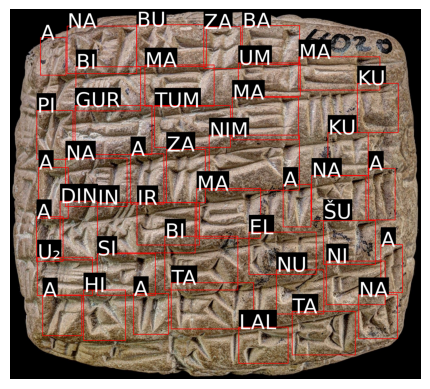

In [8]:
# detect signs
tablet_detector = sa.TabletImageDetector(model, sa.CLASSES_ABZ, SCORE_THRESHOLD, keep_crops=True)
detections = tablet_detector.detect(img)

det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(255, 0, 0)) # red for detections
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image = cropped[3]

det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [9]:
# statistics
avg_width, avg_height = sa.compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (6451, 5078, 3)
Exp image shape: (1636, 1817, 3)
Average detected sign width: 227.35, height: 196.96


In [10]:
# Build heatmap for position probability of each class

scale_factor = 10

# Create detection heatmap using extracted function
heatmap, influence_radius, sigma = sa.create_detection_heatmap(
    exp_image.detections, 
    exp_image.img.shape, 
    sa.CLASSES_ABZ, 
    scale_factor=scale_factor,
    avg_width=avg_width,
    avg_height=avg_height
)

print(f"Original image shape: {exp_image.img.shape[:2]}")
print(f"Created heatmap with shape: {heatmap.shape}")
print(f"Scale factor: 1/{scale_factor}")
print(f"Number of CLASSES_ABZ: {len(sa.CLASSES_ABZ)}")
print(f"Influence radius (scaled): {influence_radius:.2f}, sigma: {sigma:.2f}")
print(f"Heatmap generated with {len(exp_image.detections)} detections")
print(f"Heatmap value range: [{heatmap.min():.3f}, {heatmap.max():.3f}]")


Original image shape: (1636, 1817)
Created heatmap with shape: (163, 181, 173)
Scale factor: 1/10
Number of CLASSES_ABZ: 173
Influence radius (scaled): 31.82, sigma: 10.61
Heatmap generated with 43 detections
Heatmap value range: [0.000, 1.000]


Class ID for sign 'A': 11
Class ID for sign 'NA': 34


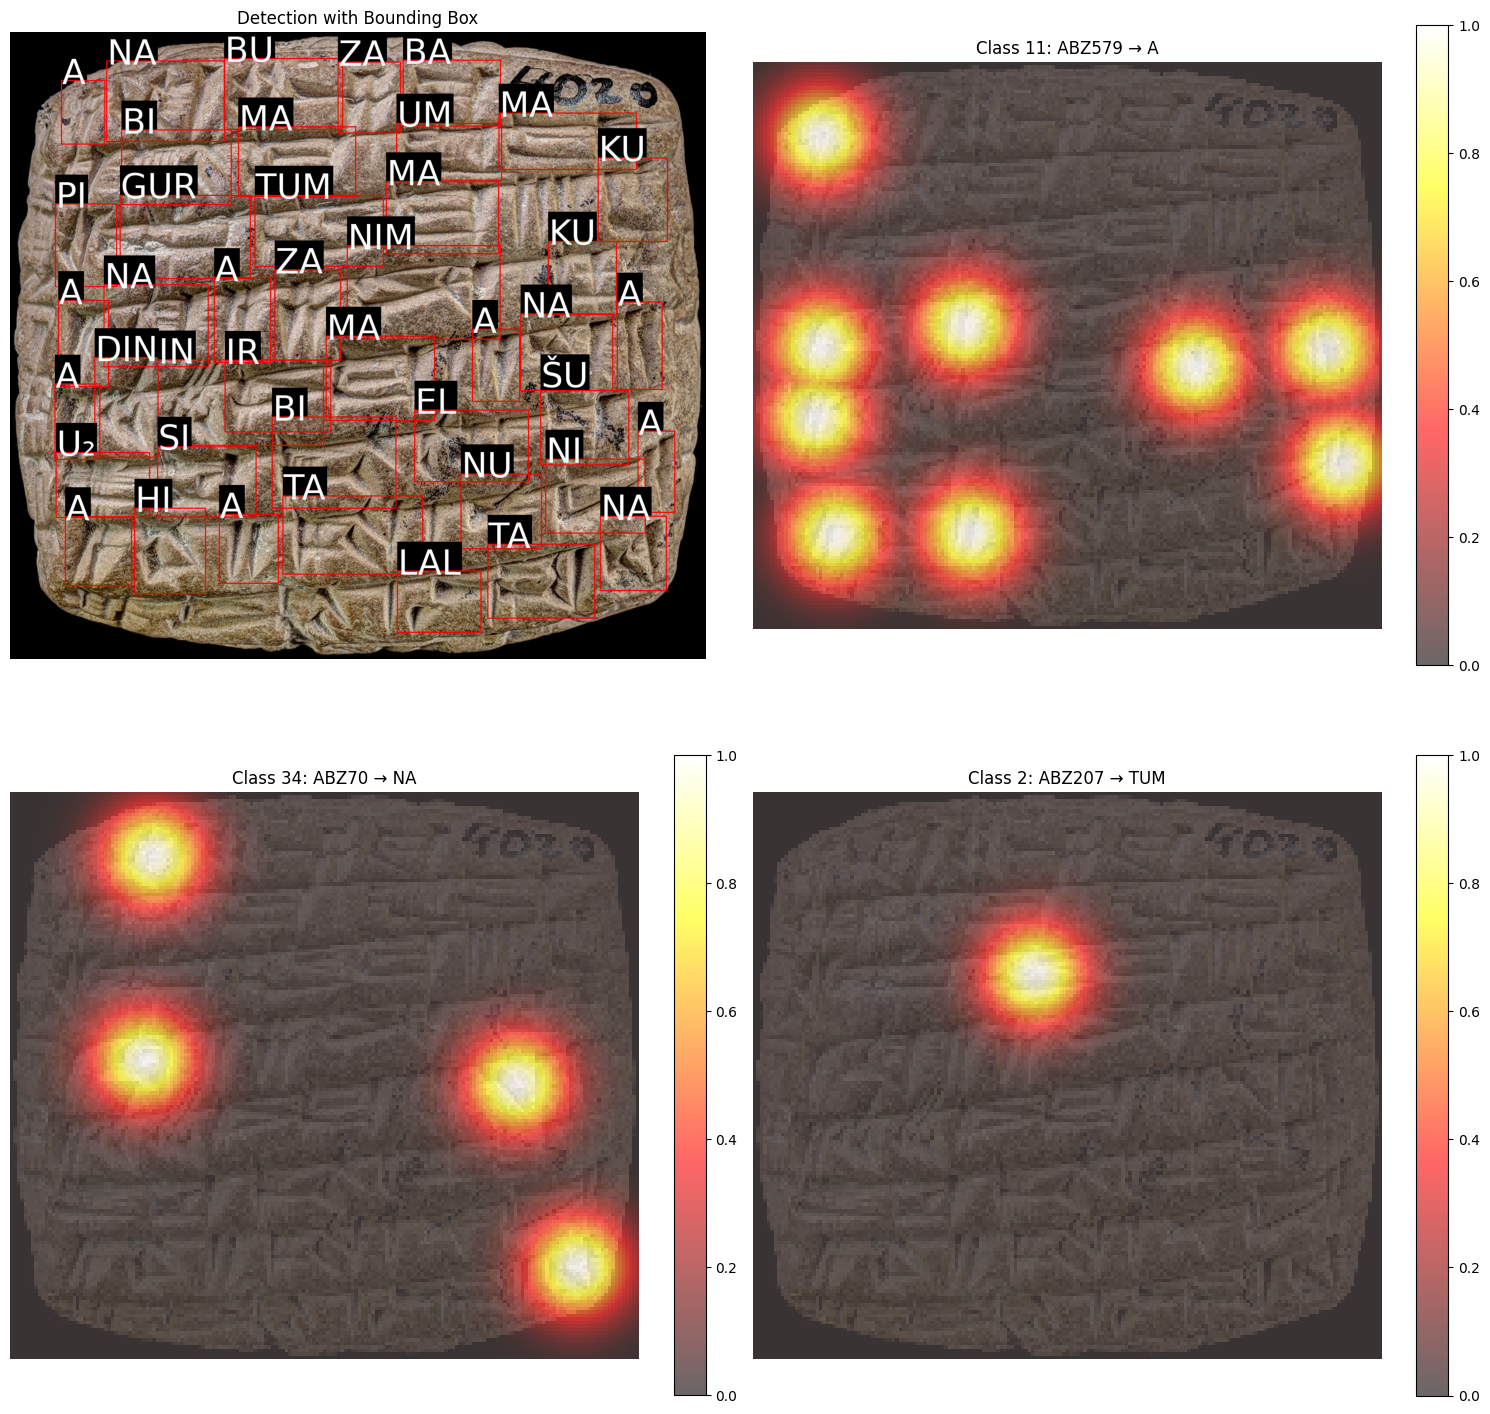

In [11]:
# Visualize exp image heatmap 

heatmap_visualizer = sa.HeatmapVisualizer()
# find class id for sign name "A"
class_id_for_A = None
class_id_for_NA = None
for i, abz_name in enumerate(sa.CLASSES_ABZ):
    if sa.abz_to_sign_name(abz_name) == "A":
        class_id_for_A = i
        break
for i, abz_name in enumerate(sa.CLASSES_ABZ):
    if sa.abz_to_sign_name(abz_name) == "NA":
        class_id_for_NA = i
        break
print(f"Class ID for sign 'A': {class_id_for_A}")
print(f"Class ID for sign 'NA': {class_id_for_NA}")
    
heatmap_visualizer.draw_heatmap(exp_image.img, heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = exp_image.detections)
heatmap_visualizer.display_result(vis_opt = "draw")

In [12]:
# Create heatmap from text_lines with synthetic sign positions

# Create text heatmap using extracted function
heatmap_text, margin, influence_radius_text, sigma_text = sa.create_text_heatmap(
    text_lines, 
    sa.CLASSES_ABZ, 
    avg_width, 
    avg_height, 
    scale_factor=scale_factor
)

max_row_length = max(len(line) for line in text_lines)
num_rows = len(text_lines)
total_signs_in_text = sum(len(line) for line in text_lines)

print(f"Text lines grid: {num_rows} rows, max {max_row_length} columns")
print(f"Average sign dimensions: width={avg_width:.2f}, height={avg_height:.2f}")
print(f"Text heatmap dimensions (after scaling): {heatmap_text.shape}")
print(f"Margin used: {margin:.2f}")
print(f"Gaussian parameters - influence radius: {influence_radius_text:.2f}, sigma: {sigma_text:.2f}")
print(f"Heatmap generated for {total_signs_in_text} signs from text_lines")
print(f"Heatmap value range: [{heatmap_text.min():.3f}, {heatmap_text.max():.3f}]")

Text lines grid: 22 rows, max 12 columns
Average sign dimensions: width=227.35, height=196.96
Text heatmap dimensions (after scaling): (478, 318, 173)
Margin used: 227.35
Gaussian parameters - influence radius: 31.82, sigma: 10.61
Heatmap generated for 143 signs from text_lines
Heatmap value range: [0.000, 1.000]


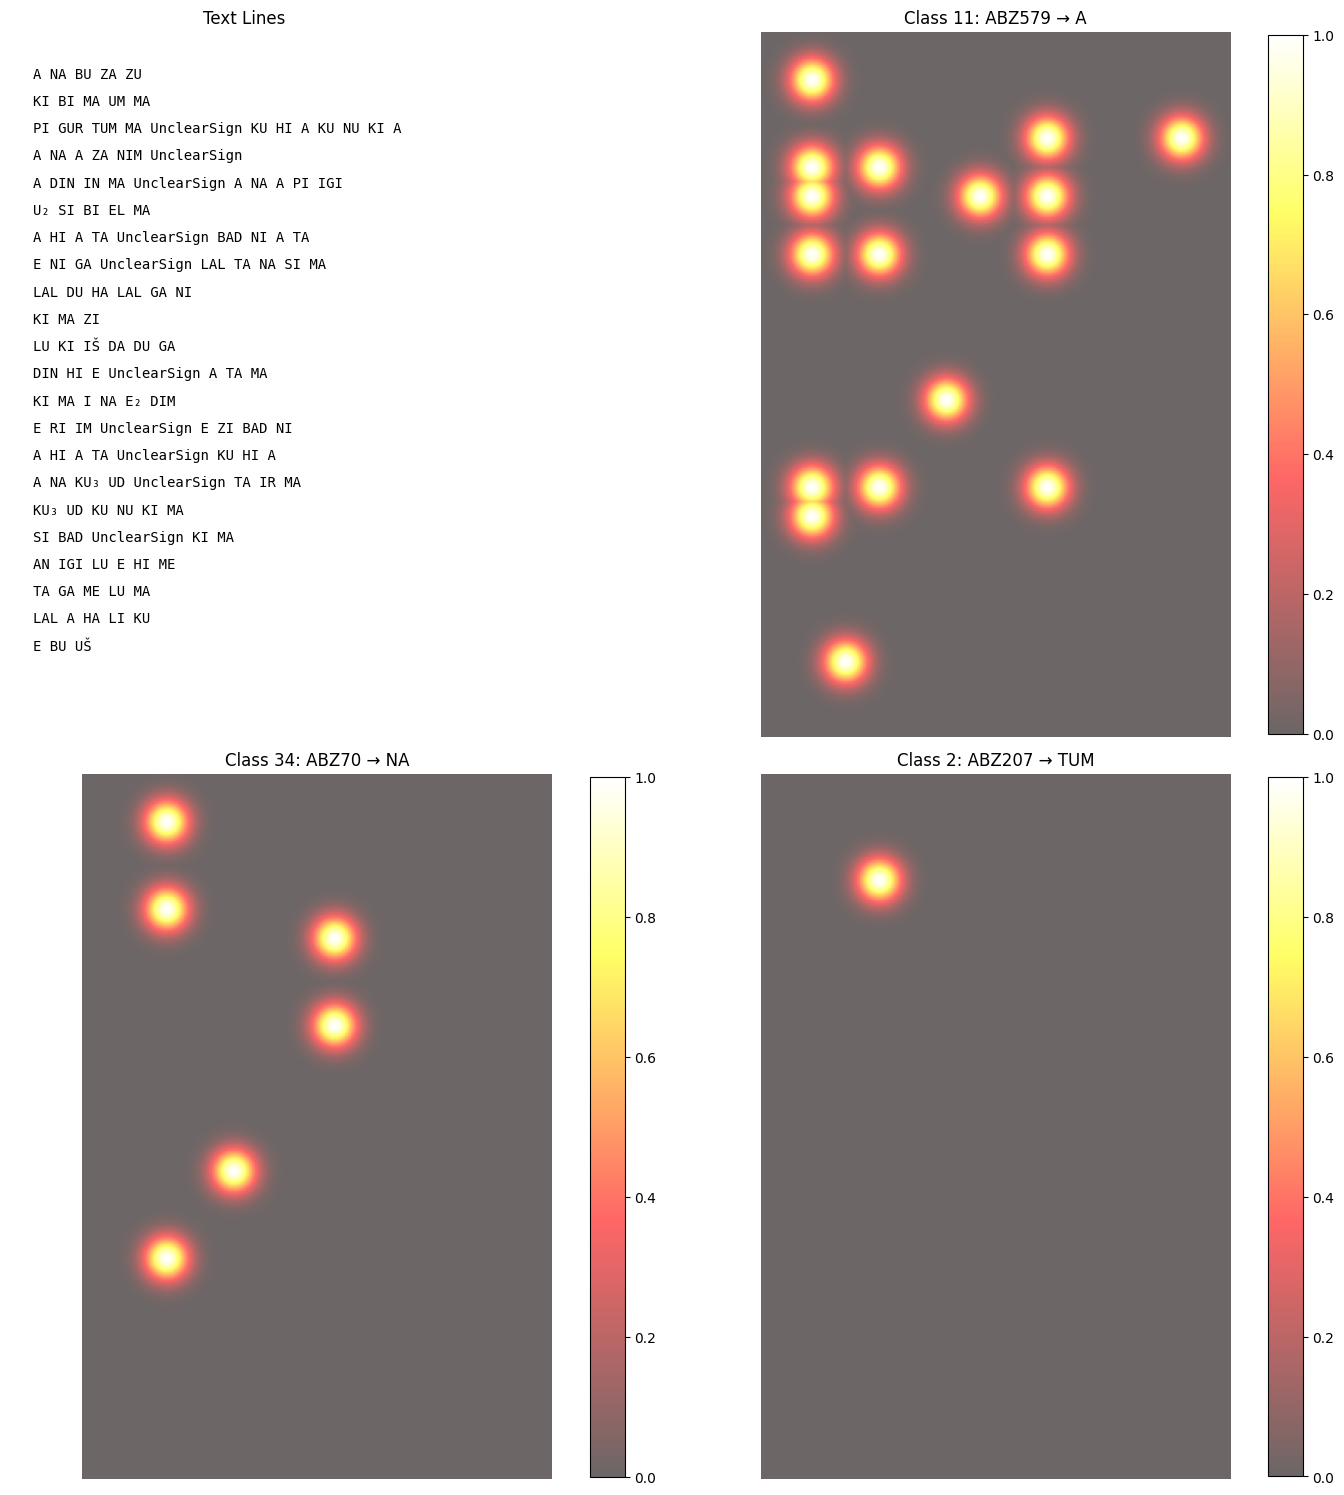

In [13]:
# Visualize text_lines heatmap

# Visualize using the same visualizer
heatmap_visualizer_text = sa.HeatmapVisualizer()

# Use the same class IDs as before for consistency
heatmap_visualizer_text.draw_heatmap(None, heatmap_text, 
                                     channels=(class_id_for_A, class_id_for_NA, 2), 
                                     detection=None, texts=text_lines)
heatmap_visualizer_text.display_result(vis_opt="draw")

In [14]:
# 1. Use normalized cross-correlation to find template position

print(f"Exp heatmap shape: {heatmap.shape}")
print(f"Text heatmap shape: {heatmap_text.shape}")

# Use extracted matching function
top_left_scaled, max_val, top_left_original = sa.match_heatmaps_ncc(
    heatmap, 
    heatmap_text, 
    scale_factor=scale_factor
)

top_left_x_text = top_left_original[0]
top_left_y_text = top_left_original[1]

print(f"Best match correlation (averaged over {heatmap.shape[2]} classes): {max_val:.4f}")
print(f"Match position in text heatmap (scaled): {top_left_scaled}")
print(f"Match position in text heatmap (original): ({top_left_x_text:.2f}, {top_left_y_text:.2f})")

# Convert to full tablet image coordinates
# The text heatmap starts with margin offset, so we need to subtract that
top_left_x_tablet = top_left_x_text - margin
top_left_y_tablet = top_left_y_text - margin

print(f"Match position in full tablet image: ({top_left_x_tablet:.2f}, {top_left_y_tablet:.2f})")

Exp heatmap shape: (163, 181, 173)
Text heatmap shape: (478, 318, 173)
Best match correlation (averaged over 173 classes): 0.2955
Match position in text heatmap (scaled): (11, 18)
Match position in text heatmap (original): (110.00, 180.00)
Match position in full tablet image: (-117.35, -47.35)


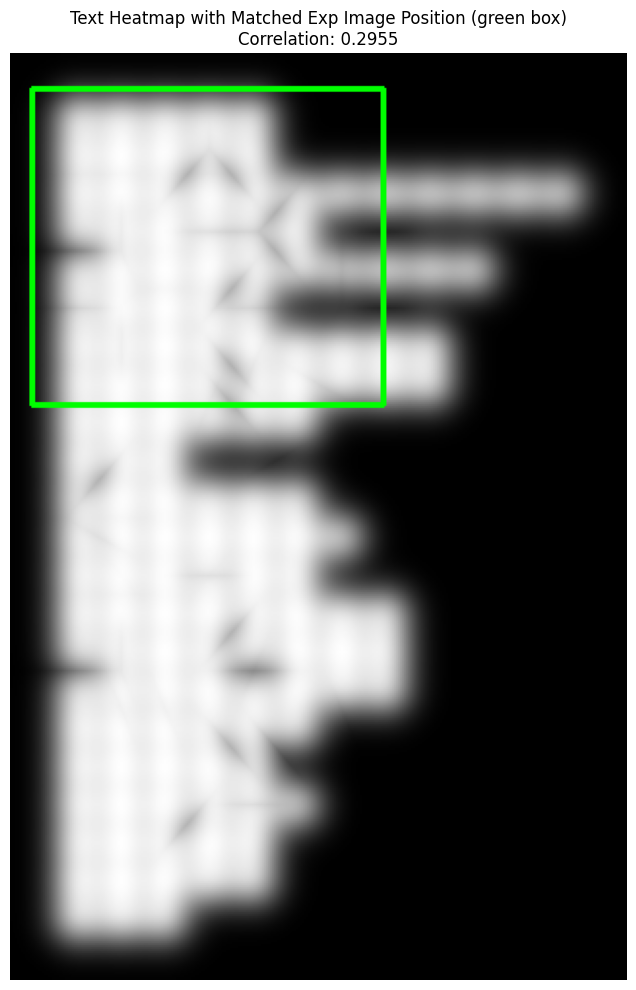

Green box shows matched position of exp image in text heatmap


In [15]:
# 2. Visualize the position of exp image heatmap in text heatmap

# Create visualization using the mixed heatmaps for display
heatmap_exp_mixed = np.mean(heatmap, axis=2)
heatmap_text_mixed = np.mean(heatmap_text, axis=2)

vis_text_heatmap = cv2.normalize(heatmap_text_mixed, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
vis_text_heatmap_rgb = cv2.cvtColor(vis_text_heatmap, cv2.COLOR_GRAY2RGB)

# Draw rectangle at matched position (in scaled coordinates)
bottom_right_scaled = (top_left_scaled[0] + heatmap_exp_mixed.shape[1], 
                       top_left_scaled[1] + heatmap_exp_mixed.shape[0])
cv2.rectangle(vis_text_heatmap_rgb, top_left_scaled, bottom_right_scaled, (0, 255, 0), 2)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.imshow(vis_text_heatmap_rgb)
plt.title(f"Text Heatmap with Matched Exp Image Position (green box)\nCorrelation: {max_val:.4f}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Green box shows matched position of exp image in text heatmap")

In [16]:
# 3. Assign sign centers from text image into exp image and create bboxes

# Get the dimensions of the exp image
exp_img_height, exp_img_width = exp_image.img.shape[:2]

# Use extracted function to create text-based detections
detection_with_texts = sa.create_text_based_detections(
    text_lines, 
    sa.CLASSES_ABZ, 
    top_left_x_text, 
    top_left_y_text, 
    margin, 
    avg_width, 
    avg_height, 
    (exp_img_width, exp_img_height)
)

print(f"Created {len(detection_with_texts)} text-based detections for exp image")
print(f"Original detections: {len(exp_image.detections)}")

# Show first few detections as example
if detection_with_texts:
    print("\nFirst 3 text-based detections:")
    for i, det in enumerate(detection_with_texts[:3]):
        print(f"  {i+1}. {det['abz_name']}: bbox={[f'{x:.1f}' for x in det['bbox']]}, center={det['center']}")

Created 49 text-based detections for exp image
Original detections: 43

First 3 text-based detections:
  1. ABZ579: bbox=['117.3', '47.3', '344.7', '244.3'], center=(231.0181127530392, 145.82473498192905)
  2. ABZ70: bbox=['344.7', '47.3', '572.0', '244.3'], center=(458.3635212550654, 145.82473498192905)
  3. ABZ371: bbox=['572.0', '47.3', '799.4', '244.3'], center=(685.7089297570915, 145.82473498192905)


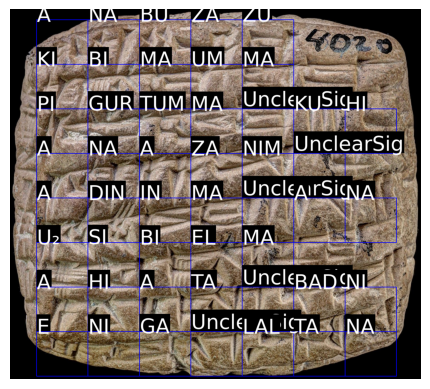

Visualized 49 text-based detections on exp image


In [17]:
# 4. Visualize detection_with_texts for exp image

text_det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 0, 255))  # blue for text-based detections
text_det_bbox_visualizer.draw_boxes(exp_image.img.copy(), detection_with_texts)
text_det_bbox_visualizer.display_result(vis_opt="draw", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text_detections.jpg"))

print(f"Visualized {len(detection_with_texts)} text-based detections on exp image")

In [18]:
for det in detection_with_texts:
    print(det['sign_name'])

A
NA
BU
ZA
ZU
KI
BI
MA
UM
MA
PI
GUR
TUM
MA
UnclearSign
KU
HI
A
NA
A
ZA
NIM
UnclearSign
A
DIN
IN
MA
UnclearSign
A
NA
U₂
SI
BI
EL
MA
A
HI
A
TA
UnclearSign
BAD
NI
E
NI
GA
UnclearSign
LAL
TA
NA


In [19]:
for k, v in sa.SignNameConverter.ABZ_TO_SIGN.items():
    if(v =='4'):
        print(k)

In [20]:
print(signs_text)
text_lines

ABZ579 ABZ70 ABZ371 ABZ586 ABZ6
ABZ461 ABZ214 ABZ342 ABZ134 ABZ342
ABZ383 ABZ111 ABZ207 ABZ342 4 ABZ536 ABZ396 ABZ579 ABZ536 ABZ75 ABZ461 ABZ579
ABZ579 ABZ70 ABZ579 ABZ586 ABZ433 P₁
ABZ579 ABZ465 ABZ148 ABZ342 P₁ ABZ579 ABZ70 ABZ579 ABZ383 ABZ449
ABZ318 ABZ112 ABZ214 ABZ564 ABZ342
ABZ579 ABZ396 ABZ579 ABZ139 P₁ ABZ69 ABZ231 ABZ579 ABZ139
ABZ308 ABZ231 ABZ319 P₁ ABZ481 ABZ139 ABZ70 ABZ112 ABZ342
ABZ481 ABZ206 ABZ589 ABZ481 ABZ319 ABZ231
ABZ461 ABZ342 ABZ84
ABZ537 ABZ461 ABZ212 ABZ335 ABZ206 ABZ319
ABZ465 ABZ396 ABZ308 P₁ ABZ579 ABZ139 ABZ342
ABZ461 ABZ342 ABZ142 ABZ70 ABZ324 ABZ94
ABZ308 ABZ86 ABZ399 P₁ ABZ308 ABZ84 ABZ69 ABZ231
ABZ579 ABZ396 ABZ579 ABZ139 P₁ ABZ536 ABZ396 ABZ579
ABZ579 ABZ70 ABZ468 ABZ381 P₁ ABZ139 ABZ232 ABZ342
ABZ468 ABZ381 ABZ536 ABZ75 ABZ461 ABZ342
ABZ112 ABZ69 ABZ435 ABZ461 ABZ342
ABZ13 ABZ449 ABZ537 ABZ308 ABZ396 ABZ532
ABZ139 ABZ319 ABZ532 ABZ537 ABZ342
ABZ481 ABZ579 ABZ589 ABZ59 ABZ536
ABZ308 ABZ371 ABZ211


[['A', 'NA', 'BU', 'ZA', 'ZU'],
 ['KI', 'BI', 'MA', 'UM', 'MA'],
 ['PI',
  'GUR',
  'TUM',
  'MA',
  'UnclearSign',
  'KU',
  'HI',
  'A',
  'KU',
  'NU',
  'KI',
  'A'],
 ['A', 'NA', 'A', 'ZA', 'NIM', 'UnclearSign'],
 ['A', 'DIN', 'IN', 'MA', 'UnclearSign', 'A', 'NA', 'A', 'PI', 'IGI'],
 ['U₂', 'SI', 'BI', 'EL', 'MA'],
 ['A', 'HI', 'A', 'TA', 'UnclearSign', 'BAD', 'NI', 'A', 'TA'],
 ['E', 'NI', 'GA', 'UnclearSign', 'LAL', 'TA', 'NA', 'SI', 'MA'],
 ['LAL', 'DU', 'HA', 'LAL', 'GA', 'NI'],
 ['KI', 'MA', 'ZI'],
 ['LU', 'KI', 'IŠ', 'DA', 'DU', 'GA'],
 ['DIN', 'HI', 'E', 'UnclearSign', 'A', 'TA', 'MA'],
 ['KI', 'MA', 'I', 'NA', 'E₂', 'DIM'],
 ['E', 'RI', 'IM', 'UnclearSign', 'E', 'ZI', 'BAD', 'NI'],
 ['A', 'HI', 'A', 'TA', 'UnclearSign', 'KU', 'HI', 'A'],
 ['A', 'NA', 'KU₃', 'UD', 'UnclearSign', 'TA', 'IR', 'MA'],
 ['KU₃', 'UD', 'KU', 'NU', 'KI', 'MA'],
 ['SI', 'BAD', 'UnclearSign', 'KI', 'MA'],
 ['AN', 'IGI', 'LU', 'E', 'HI', 'ME'],
 ['TA', 'GA', 'ME', 'LU', 'MA'],
 ['LAL', 'A', 'HA', 'LI'

In [21]:
print(model.dataset_meta["classes"])

['TU', '|U.GUD|', 'TUM', 'LA', 'TA', 'GAR', 'GAL', 'I', 'TI', 'LI', 'ZA', 'A', 'DI', 'MI', 'RI', 'IŠ', 'BA', 'LU', 'TE', 'DA', '|GUD×KUR|', 'MA', 'E₂', 'DIŠ', 'MU', 'DU', 'ŠU₂', 'EN', 'KUL', 'SI', '|I.A|', 'HI', 'MUŠ₃', 'AN', 'NA', 'BAD', 'AMAR', 'UD', 'UnclearSign', '|HI×BAD|', '|UD×(U.U.U)|', 'AB', 'AK', 'LUGAL', 'DIN', 'KI', 'DUN₃@g', 'KU₃', 'AŠ', 'IGI', 'U₂', 'ŠA₃', 'BI', 'GUR', 'ŠE', 'ZI', 'GA', 'SILA₃', 'ŠID', '|SAL.TUG₂|', 'SU', 'KAK', 'MAŠ', 'TUR', 'ŠEŠ', 'LU₂', 'IA₂', 'UR', 'KAL', '|ŠEŠ.KI|', 'ZU', 'ŠU', 'NE', 'IM', 'RA', '|U.U|', 'ZAG', '|DIŠ.DIŠ.DIŠ|', 'GA₂', 'IN', 'KIN', 'TAR', 'MAH', 'LAL', 'KID', 'GABA', 'KA', 'RU', 'ŠA', '|HI×NUN|', 'ME', 'BU', 'NI', 'IG', 'MES', 'PA', 'SAG', 'U', 'E', 'GUM', 'GIŠ', '|U.KA|', 'LUM', '|HI×AŠ₂|', 'HA', 'UŠ', '|U.U.U|', 'MIN', 'NAM', 'NU', 'AL', 'AB₂', 'IB', 'UM', 'KU', 'SUR', 'MEŠ', 'TUG₂', 'TAG', 'DIM', 'BAL', 'IR', 'ERIN₂', 'PAP', 'SA', '|PIRIG×ZA|', 'UB', 'URU', '|U.5(DIŠ)|', 'DAM', 'GAR₃', '|EN.ZU|', 'ZE₂', 'AD', 'APIN', 'EL', 'PI', 'A